# Análisis de errores por slices y plan de mitigación

## Configuración

In [1]:
import warnings, os, json, itertools, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve, silhouette_score,
                             brier_score_loss)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
import lightgbm as lgb
import shap

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
S2_COLOR, S3_COLOR, ENS_COLOR = 'slategray', 'darkcyan', 'darkorange'
def coral(s):  # resaltado coral para valores clave en prints
    return f'\033[91m{s}\033[0m'

os.makedirs('outputs_sprint4', exist_ok=True)

## Carga de datos

In [2]:
df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES_BASE = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()
# Auxiliares para slices (NO son features del modelo): coordenadas, nivel y ley de Au
AUX = df[['East', 'North', 'Level', 'Au_ppm']].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
AUX_tr = AUX.loc[X_train.index].copy()
AUX_te = AUX.loc[X_test.index].copy()

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f'Features base: {len(FEATURES_BASE)} | Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Prevalencia positiva (train): {y_train.mean():.3f} | (test): {y_test.mean():.3f}')

Features base: 46 | Train: (1705, 46) | Test: (427, 46)
Prevalencia positiva (train): 0.122 | (test): 0.122


In [3]:
# --- Elementos no económicos (filtro de censura > 30 %) ---
ECONOMICOS = ['Au_ppm', 'Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']
UMBRAL_CENS = 0.30
df_raw = pd.read_csv('../data/raw/DataSet.csv')
def frac_censurado(col):
    if col not in df_raw.columns:
        return 0.0
    s = df_raw[col].astype(str).str.strip()
    return float(s.str.startswith(('<', '>')).mean())
no_econ_all = [c for c in FEATURES_BASE if c not in ECONOMICOS]
NO_ECON = [c for c in no_econ_all if frac_censurado(c) <= UMBRAL_CENS]
print(f'No económicos válidos para FE: {len(NO_ECON)} (de {len(no_econ_all)})')

No económicos válidos para FE: 39 (de 42)


In [4]:
# --- Base log (skew>1.5) + log-ratios exhaustivos + correlación |r|>0.95 + VIF<10 ---
sk = X_train.apply(lambda c: skew(c.dropna()))
ASIM = sk[sk > 1.5].index.tolist()
X_train_logbase = X_train.copy(); X_test_logbase = X_test.copy()
for c in ASIM:
    X_train_logbase[c] = np.log1p(X_train[c].clip(lower=0))
    X_test_logbase[c]  = np.log1p(X_test[c].clip(lower=0))

EPS = 1e-9
pares = list(itertools.combinations(NO_ECON, 2))
def construir_ratios(Xsrc):
    d = {f'{a}__over__{b}': np.log(Xsrc[a].clip(lower=EPS) / Xsrc[b].clip(lower=EPS))
         for a, b in pares}
    return pd.DataFrame(d, index=Xsrc.index)
R_train = construir_ratios(X_train).replace([np.inf, -np.inf], np.nan)
R_test  = construir_ratios(X_test).replace([np.inf, -np.inf], np.nan)
med_r = R_train.median()
R_train = R_train.fillna(med_r); R_test = R_test.fillna(med_r)

UMBRAL_CORR = 0.95
corr_abs = R_train.corr().abs()
triu = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
drop_corr = [col for col in triu.columns if (triu[col] > UMBRAL_CORR).any()]
R_train_c = R_train.drop(columns=drop_corr); R_test_c = R_test.drop(columns=drop_corr)

UMBRAL_VIF = 10.0
def vif_iterativo(dframe, umbral=UMBRAL_VIF, max_iter=1000):
    cols = list(dframe.columns)
    for _ in range(max_iter):
        if len(cols) <= 1:
            break
        C = dframe[cols].corr().values
        try:
            inv = np.linalg.inv(C)
        except np.linalg.LinAlgError:
            inv = np.linalg.pinv(C)
        vifs = np.diag(inv)
        imax = int(np.argmax(vifs)); vmax = float(vifs[imax])
        if vmax > umbral:
            cols.pop(imax)
        else:
            break
    return cols
t0 = time.time()
RATIOS_SEL = vif_iterativo(R_train_c)
print(f'Ratios: {R_train.shape[1]} creados → {R_train_c.shape[1]} tras corr → '
      f'{len(RATIOS_SEL)} tras VIF ({time.time()-t0:.0f}s)')

Ratios: 741 creados → 555 tras corr → 93 tras VIF (235s)


In [5]:
# --- Clustering (KMeans + GMM + DBSCAN → 5 features) en el espacio LOG de los no económicos ---
def features_cluster(Xtr_esp, Xte_esp, etiqueta):
    sc = StandardScaler().fit(Xtr_esp)
    Ztr, Zte = sc.transform(Xtr_esp), sc.transform(Xte_esp)
    sils = [silhouette_score(Ztr, KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(Ztr))
            for k in range(2, 11)]
    k_km = int(np.argmax(sils)) + 2
    km = KMeans(n_clusters=k_km, random_state=SEED, n_init=10).fit(Ztr)
    bics = [GaussianMixture(n_components=k, random_state=SEED).fit(Ztr).bic(Ztr) for k in range(2, 11)]
    k_gmm = int(np.argmin(bics)) + 2
    gm = GaussianMixture(n_components=k_gmm, random_state=SEED).fit(Ztr)
    nn = NearestNeighbors(n_neighbors=10).fit(Ztr)
    kdist = np.sort(nn.kneighbors(Ztr)[0][:, -1]); eps = float(np.percentile(kdist, 90))
    db_tr = DBSCAN(eps=eps, min_samples=10).fit_predict(Ztr)
    db_te = DBSCAN(eps=eps, min_samples=10).fit_predict(Zte)
    def dist_centroides(Z):
        return np.min(np.linalg.norm(Z[:, None, :] - km.cluster_centers_[None, :, :], axis=2), axis=1)
    ftr = pd.DataFrame({f'kmeans_label_{etiqueta}': km.labels_,
        f'kmeans_dist_{etiqueta}': dist_centroides(Ztr),
        f'gmm_label_{etiqueta}': gm.predict(Ztr),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Ztr).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_tr == -1).astype(int)}, index=Xtr_esp.index)
    fte = pd.DataFrame({f'kmeans_label_{etiqueta}': km.predict(Zte),
        f'kmeans_dist_{etiqueta}': dist_centroides(Zte),
        f'gmm_label_{etiqueta}': gm.predict(Zte),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Zte).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_te == -1).astype(int)}, index=Xte_esp.index)
    return ftr, fte

Xtr_log = np.log1p(X_train[NO_ECON].clip(lower=0))
Xte_log = np.log1p(X_test[NO_ECON].clip(lower=0))
cl_log_tr, cl_log_te = features_cluster(Xtr_log, Xte_log, 'log')

# Set E5 completo (144 features) = punto de partida del Sprint 3
X_S2_tr = pd.concat([X_train_logbase, R_train_c[RATIOS_SEL], cl_log_tr], axis=1)
X_S2_te = pd.concat([X_test_logbase,  R_test_c[RATIOS_SEL],  cl_log_te], axis=1)
FEATURES_S2 = list(X_S2_tr.columns)
print(f'Set E5 (S2): {len(FEATURES_S2)} features = {len(FEATURES_BASE)} base '
      f'+ {len(RATIOS_SEL)} ratios + {cl_log_tr.shape[1]} clustering')

Set E5 (S2): 144 features = 46 base + 93 ratios + 5 clustering


In [6]:
# --- Fallback (valores confirmados del Sprint 3) ---
PARAMS_S2_FB = {'learning_rate': 0.1287222365527861, 'n_estimators': 167,
                'num_leaves': 48, 'min_child_samples': 27}
PARAMS_S3_FB = {'n_estimators': 232, 'num_leaves': 59, 'learning_rate': 0.04415508827314991,
                'subsample': 0.7316763198578394, 'colsample_bytree': 0.9539086384084597,
                'min_child_samples': 11, 'reg_lambda': 0.8960901541288493, 'subsample_freq': 1}
SET_S3_FB = ['Ag_ppm','Te_ppm','Se_ppm','Sb_ppm','Cr_ppm__over__Mg_per','Ba_ppm__over__Sb_ppm',
    'Be_ppm__over__Zr_ppm','Mn_ppm__over__Sb_ppm','kmeans_dist_log','Al_per__over__Sc_ppm',
    'Ce_ppm__over__Fe_per','Fe_per__over__Sn_ppm','Al_per__over__Th_ppm','Ba_ppm__over__Na_per',
    'La_ppm','Cu_ppm','Sn_ppm__over__V_ppm','Ti_per__over__Zr_ppm','Ta_ppm','Sr_ppm',
    'Ba_ppm__over__Rb_ppm','gmm_prob_max_log','S_per','Be_ppm__over__Ni_ppm','Ti_per__over__V_ppm',
    'Cs_ppm','Rb_ppm','Nb_ppm__over__Tl_ppm','Th_ppm__over__W_ppm','Mg_per','Y_ppm',
    'K_per__over__Rb_ppm','Cs_ppm__over__Ni_ppm','Bi_ppm__over__U_ppm','Na_per','Mg_per__over__Sb_ppm',
    'Ga_ppm','Be_ppm__over__Co_ppm','Ba_ppm__over__Cd_ppm','Sn_ppm__over__Sr_ppm','Mg_per__over__Mo_ppm',
    'As_ppm','Pb_ppm','Ga_ppm__over__U_ppm','Ca_per__over__Cr_ppm','As_ppm__over__Fe_per',
    'Hf_ppm__over__W_ppm']

try:
    with open('outputs_sprint3/final_resumen_sprint3.json') as f:
        R3 = json.load(f)
    PARAMS_S2   = R3.get('params_s2', PARAMS_S2_FB)
    PARAMS_S3   = R3.get('params_s3', PARAMS_S3_FB)
    set_S3      = R3.get('set_s3_features', SET_S3_FB)
    CALIBRACION = R3.get('calibracion', 'isotonic')
    UMBRAL_S3   = float(R3.get('umbral', 0.4683))
    F1_CV_S3    = float(R3.get('f1_final', 0.7706))
    F1_HO_S3    = float(R3.get('metricas_finales', {}).get('F1', 0.7619))
    print('Config del Sprint 3 cargada desde final_resumen_sprint3.json')
except FileNotFoundError:
    PARAMS_S2, PARAMS_S3, set_S3 = PARAMS_S2_FB, PARAMS_S3_FB, SET_S3_FB
    CALIBRACION, UMBRAL_S3, F1_CV_S3, F1_HO_S3 = 'isotonic', 0.4683, 0.7706, 0.7619
    print('final_resumen_sprint3.json no encontrado → usando fallback confirmado')

F1_SPRINT2 = 0.754   # F1_CV del Sprint 2 (referencia)
BALANCEO = 'SMOTETomek'
print(f'set_S3: {len(set_S3)} features | Calibración: {CALIBRACION} | Umbral S3: {UMBRAL_S3:.4f}')
print(f'F1_CV S3 (referencia): {F1_CV_S3:.4f} | F1 hold-out S3 (referencia): {F1_HO_S3:.4f}')

Config del Sprint 3 cargada desde final_resumen_sprint3.json
set_S3: 47 features | Calibración: isotonic | Umbral S3: 0.4683
F1_CV S3 (referencia): 0.7706 | F1 hold-out S3 (referencia): 0.7619


In [7]:
# --- Utilidades compartidas (idénticas al protocolo del proyecto) ---
def make_pipe(params):
    '''Pipeline base: StandardScaler → SMOTETomek (DENTRO del fold) → LightGBM.'''
    return ImbPipeline([
        ('sc', StandardScaler()),
        ('bal', SMOTETomek(random_state=SEED)),
        ('clf', lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, n_jobs=-1)),
    ])

def f1_cv(Xin, ytr, params, features=None):
    '''MÉTRICA PRIMARIA: F1 clase positiva por CV 5-fold. Devuelve (media, std).'''
    Xuse = Xin[features] if features is not None else Xin
    sc = cross_val_score(make_pipe(params), Xuse, ytr, cv=CV5, scoring='f1', n_jobs=-1)
    return sc.mean(), sc.std()

def oof_proba(factory, X, yv):
    '''Probabilidades OOF: entrena en cada fold de train y predice el fold de validación.
    El mismo CV5 (misma semilla) garantiza que las OOF de distintos modelos queden ALINEADAS
    por posición (mismas filas de validación en cada fold).'''
    oof = np.zeros(len(yv), dtype=float)
    for tr_idx, va_idx in CV5.split(X, yv):
        est = factory()
        est.fit(X.iloc[tr_idx], yv.iloc[tr_idx])
        oof[va_idx] = est.predict_proba(X.iloc[va_idx])[:, 1]
    return oof

def best_thr_f1(y_true, p):
    '''Umbral que maximiza F1 sobre (y_true, p). Devuelve (umbral, f1).'''
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1g = 2 * prec * rec / (prec + rec + 1e-12)
    i = int(np.nanargmax(f1g[:-1]))
    return float(thr[i]), float(f1g[i])

def f1_en_umbral(y_true, p, thr):
    return f1_score(y_true, (p >= thr).astype(int))

In [8]:
# Modelo S2 para SHAP (SMOTETomek sobre el training completo; LightGBM invariante a escala)
Xtr_res, ytr_res = SMOTETomek(random_state=SEED).fit_resample(X_S2_tr, y_train)
clf_shap = lgb.LGBMClassifier(**PARAMS_S2, random_state=SEED, verbose=-1, n_jobs=-1)
clf_shap.fit(Xtr_res, ytr_res)

explainer = shap.TreeExplainer(clf_shap)
sv = explainer.shap_values(X_S2_tr)
if isinstance(sv, list):
    sv = sv[1]
sv = np.asarray(sv)

imp = np.abs(sv).mean(axis=0)
imp_ser = pd.Series(imp, index=FEATURES_S2).sort_values(ascending=False)
imp_df = imp_ser.reset_index(); imp_df.columns = ['feature', 'mean_abs_shap']
imp_df['cum_frac'] = imp_df['mean_abs_shap'].cumsum() / imp_df['mean_abs_shap'].sum()
imp_df.to_csv('outputs_sprint4/shap_ranking_s2.csv', index=False)

# Orden SHAP completo (para el barrido de re-inclusión A2)
ORDEN_SHAP = imp_df['feature'].tolist()
n_95 = int((imp_df['cum_frac'] <= 0.95).sum()) + 1
print(f'SHAP recomputado sobre {X_S2_tr.shape[0]}×{X_S2_tr.shape[1]} | 95% |SHAP| = {n_95} features')
print(imp_df.head(12).to_string(index=False))

SHAP recomputado sobre 1705×144 | 95% |SHAP| = 101 features
             feature  mean_abs_shap  cum_frac
              Ag_ppm       6.451571  0.293229
              Te_ppm       0.963774  0.337033
              Se_ppm       0.787476  0.372825
              Sb_ppm       0.664114  0.403009
Cr_ppm__over__Mg_per       0.589916  0.429822
Ba_ppm__over__Sb_ppm       0.556116  0.455097
Be_ppm__over__Zr_ppm       0.476668  0.476762
Mn_ppm__over__Sb_ppm       0.427544  0.496195
     kmeans_dist_log       0.344833  0.511868
Al_per__over__Sc_ppm       0.285996  0.524866
Ce_ppm__over__Fe_per       0.281984  0.537683
Fe_per__over__Sn_ppm       0.271893  0.550040


In [9]:
# Elementos BASE más importantes por SHAP (sin '__over__') → definen los slices geoquímicos
ELEM_BASE_SHAP = [f for f in ORDEN_SHAP if f in FEATURES_BASE][:6]
print('Elementos base top-SHAP (para terciles geoquímicos):', ELEM_BASE_SHAP)

Elementos base top-SHAP (para terciles geoquímicos): ['Ag_ppm', 'Te_ppm', 'Se_ppm', 'Sb_ppm', 'La_ppm', 'Cu_ppm']


In [10]:
# X_S3 = subconjunto set_S3 del set E5
X_S3_tr = X_S2_tr[set_S3].copy()
X_S3_te = X_S2_te[set_S3].copy()

# Reproducción F1_CV (métrica primaria)
f1cv_s2, sd_s2 = f1_cv(X_S2_tr, y_train, PARAMS_S2)
f1cv_s3, sd_s3 = f1_cv(X_S3_tr, y_train, PARAMS_S3)
print(f'F1_CV S2 (144 feats): {f1cv_s2:.4f} ± {sd_s2:.4f}  (ref Sprint 2 ≈ {F1_SPRINT2:.4f})')
print(f'F1_CV S3 ( 47 feats): {f1cv_s3:.4f} ± {sd_s3:.4f}  (ref Sprint 3 = {F1_CV_S3:.4f})')

F1_CV S2 (144 feats): 0.7540 ± 0.0382  (ref Sprint 2 ≈ 0.7540)
F1_CV S3 ( 47 feats): 0.7706 ± 0.0080  (ref Sprint 3 = 0.7706)


In [11]:
# Probabilidades OOF ALINEADAS (mismo CV5 → mismas filas de validación por fold)
print('Calculando OOF S2 (raw) y S3 (raw) ...')
fac_s2      = lambda: make_pipe(PARAMS_S2)
fac_s3_raw  = lambda: make_pipe(PARAMS_S3)
p_S2_oof = oof_proba(fac_s2,     X_S2_tr, y_train)   # S2 crudo
p_S3_oof = oof_proba(fac_s3_raw, X_S3_tr, y_train)   # S3 CRUDO → baseline (consistente con F1_CV)
# (La calibración isotónica se evalúa en A4 recalibrando p_S3_oof de forma honesta por KFold.)

# Baseline Fase A = S3 SIN calibrar, umbral re-optimizado sobre OOF
yv = np.asarray(y_train)
UMBRAL_BASE, F1_BASE_OOF = best_thr_f1(yv, p_S3_oof)
BRIER_BASE = brier_score_loss(yv, p_S3_oof)
print(f'BASELINE (S3 SIN calibrar OOF): umbral={coral(f"{UMBRAL_BASE:.4f}")} '
      f'F1_OOF={coral(f"{F1_BASE_OOF:.4f}")} Brier={BRIER_BASE:.5f}')
print(f'  Comprobación de consistencia: F1_OOF crudo ({F1_BASE_OOF:.4f}) ≈ F1_CV S3 ({f1cv_s3:.4f})')
print(f'  (F1 hold-out S3 de referencia, informativo: {F1_HO_S3:.4f})')

Calculando OOF S2 (raw) y S3 (raw) ...
BASELINE (S3 SIN calibrar OOF): umbral=0.5069 F1_OOF=0.7707 Brier=0.04919
  Comprobación de consistencia: F1_OOF crudo (0.7707) ≈ F1_CV S3 (0.7706)
  (F1 hold-out S3 de referencia, informativo: 0.7619)


## Slides

In [12]:
# --- Predicción OOF del baseline (S3 calibrado + umbral global) ---
y_pred_base = (p_S3_oof >= UMBRAL_BASE).astype(int)
F1_GLOBAL = f1_score(yv, y_pred_base)

def bootstrap_f1_ic(y_true, y_pred, n=1000, seed=SEED):
    '''IC95% del F1 por bootstrap sobre pares (y_true, y_pred).'''
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); m = len(y_true)
    stats = []
    for _ in range(n):
        idx = rng.randint(0, m, m)
        if y_true[idx].sum() == 0:
            continue
        stats.append(f1_score(y_true[idx], y_pred[idx], zero_division=0))
    if not stats:
        return np.nan, np.nan
    return float(np.percentile(stats, 2.5)), float(np.percentile(stats, 97.5))

print(f'F1 GLOBAL (OOF baseline): {coral(f"{F1_GLOBAL:.4f}")}  |  umbral={UMBRAL_BASE:.4f}')

F1 GLOBAL (OOF baseline): 0.7707  |  umbral=0.5069


In [13]:
# --- Bordes derivados de TRAIN para reconstruir slices IDÉNTICOS en test (sin fuga) ---
EDGES = {}
for elem in ELEM_BASE_SHAP:
    try:
        _, b = pd.qcut(X_train[elem], 3, labels=False, retbins=True, duplicates='drop')
        if len(b) == 4:                      # exactamente 3 terciles
            EDGES['geoq_' + elem] = b
    except Exception:
        pass
_, bz = pd.qcut(AUX_tr['Level'], 3, labels=False, retbins=True, duplicates='drop')
EDGES['franja_Z'] = bz
MED_E, MED_N = AUX_tr['East'].median(), AUX_tr['North'].median()

def _corta(vals, bins, labels):
    '''Asigna categoría por los bordes de TRAIN (clip a los extremos).'''
    idx = np.clip(np.digitize(vals, bins[1:-1], right=False), 0, len(labels) - 1)
    return np.asarray(labels)[idx]

def construir_particiones(Xb, AUXsrc, dec_s2, dec_s3):
    '''Reconstruye TODAS las particiones decisorias para un set arbitrario (train o test).'''
    part = {}
    for elem in ELEM_BASE_SHAP:
        key = 'geoq_' + elem
        if key in EDGES:
            part[key] = _corta(Xb[elem].values, EDGES[key], ['bajo', 'medio', 'alto'])
    q_ew = np.where(AUXsrc['East'].values >= MED_E, 'E', 'W')
    q_ns = np.where(AUXsrc['North'].values >= MED_N, 'N', 'S')
    part['cuadrante_XY'] = np.char.add(q_ns, q_ew)                      # NE, NW, SE, SW
    part['franja_Z'] = _corta(AUXsrc['Level'].values, EDGES['franja_Z'],
                              ['somero', 'medio', 'profundo'])
    part['concordancia_S2S3'] = np.where((dec_s2 == 1) & (dec_s3 == 1), 'ambos_pos',
        np.where((dec_s2 == 0) & (dec_s3 == 0), 'ambos_neg', 'discrepan'))
    return part

# Particiones de TRAIN (con decisiones OOF de cada modelo)
dec_s2_tr = (p_S2_oof >= 0.5).astype(int)
dec_s3_tr = (p_S3_oof >= UMBRAL_BASE).astype(int)
PARTICIONES = construir_particiones(X_train, AUX_tr, dec_s2_tr, dec_s3_tr)
OBSERVA = {'dbscan_outlier': np.where(X_S2_tr['dbscan_outlier_log'].values == 1,
                                      'outlier', 'normal')}
print('Particiones que deciden:', list(PARTICIONES.keys()))
print('Solo observación      :', list(OBSERVA.keys()))

Particiones que deciden: ['geoq_Ag_ppm', 'geoq_Sb_ppm', 'geoq_La_ppm', 'geoq_Cu_ppm', 'cuadrante_XY', 'franja_Z', 'concordancia_S2S3']
Solo observación      : ['dbscan_outlier']


In [14]:
# --- F1 + IC95% por cada categoría de cada slice ---
def evaluar_slices(dic_part, deciden):
    filas = []
    for nombre, arr in dic_part.items():
        for cat in pd.unique(arr):
            m = (arr == cat)
            n = int(m.sum()); npos = int(yv[m].sum())
            if n == 0:
                continue
            f1s = f1_score(yv[m], y_pred_base[m], zero_division=0)
            lo, hi = bootstrap_f1_ic(yv[m], y_pred_base[m])
            grande = (n >= 30) and (npos >= 5)
            problematico = bool(deciden and grande and (not np.isnan(hi)) and (hi < F1_GLOBAL))
            filas.append({'slice': nombre, 'categoria': str(cat), 'n': n, 'positivos': npos,
                          'F1': round(f1s, 4), 'IC95_inf': round(lo, 4) if not np.isnan(lo) else np.nan,
                          'IC95_sup': round(hi, 4) if not np.isnan(hi) else np.nan,
                          'decide': deciden, 'grande': grande, 'problematico': problematico})
    return filas

filas = evaluar_slices(PARTICIONES, True) + evaluar_slices(OBSERVA, False)
slices_df = pd.DataFrame(filas).sort_values(['decide', 'F1'], ascending=[False, True]).reset_index(drop=True)
slices_df.to_csv('outputs_sprint4/metricas_por_slice.csv', index=False)

PROBLEMATICOS = slices_df[slices_df['problematico']].copy()
print(f'Slices evaluados: {len(slices_df)} | problemáticos (grandes, decisorios, IC95_sup<F1_global): '
      f'{coral(len(PROBLEMATICOS))}')
print(slices_df.head(20).to_string(index=False))

Slices evaluados: 24 | problemáticos (grandes, decisorios, IC95_sup<F1_global): 5
            slice categoria    n  positivos     F1  IC95_inf  IC95_sup  decide  grande  problematico
      geoq_Ag_ppm      bajo  564          1 0.0000    0.0000    0.0000    True   False         False
concordancia_S2S3 ambos_neg 1479         43 0.0000    0.0000    0.0000    True    True          True
      geoq_Ag_ppm     medio  572         17 0.1600    0.0000    0.3530    True    True          True
      geoq_Sb_ppm      bajo  568          6 0.2222    0.0000    0.5885    True    True          True
concordancia_S2S3 discrepan   37         13 0.5641    0.3636    0.7180    True    True          True
      geoq_Sb_ppm     medio  567         38 0.6301    0.4745    0.7467    True    True          True
     cuadrante_XY        SE  407         20 0.6341    0.4499    0.7843    True    True         False
      geoq_La_ppm      alto  569         11 0.7000    0.4000    0.8889    True    True         False
         

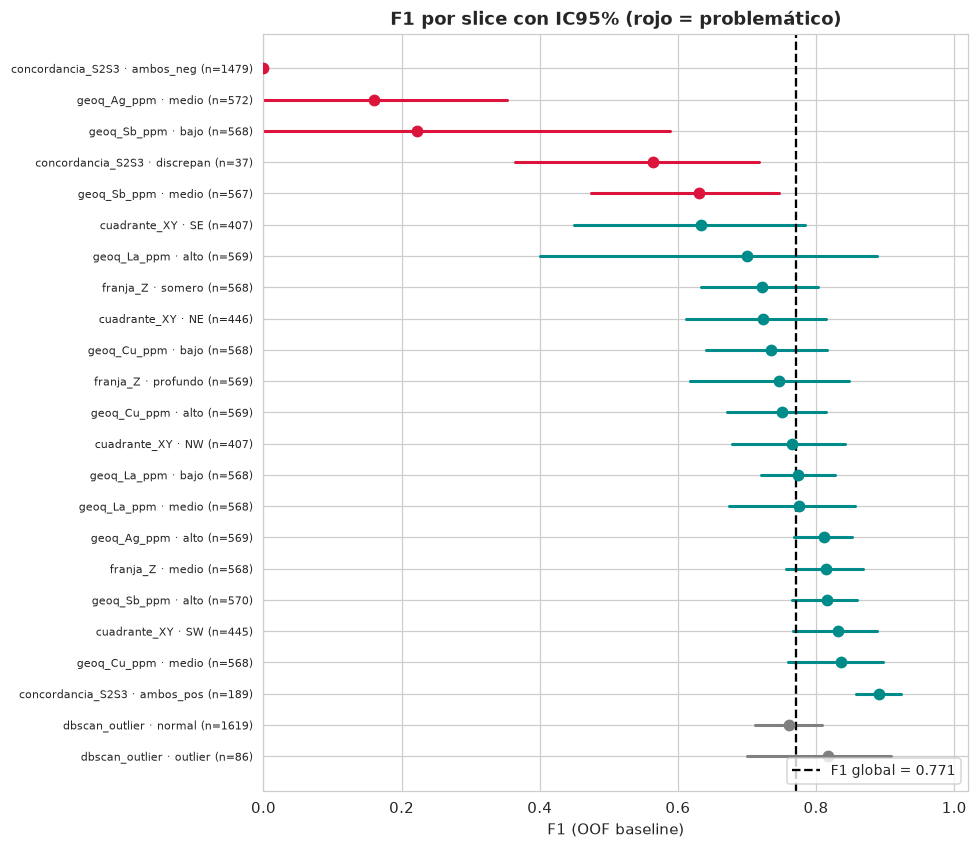

In [15]:
# --- Forest plot: F1 por slice con IC95% (solo categorías grandes) ---
plot_df = slices_df[slices_df['grande']].copy().reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, max(4, 0.34 * len(plot_df))))
for i, r in plot_df.iterrows():
    col = 'crimson' if r['problematico'] else (S3_COLOR if r['decide'] else 'gray')
    ax.plot([r['IC95_inf'], r['IC95_sup']], [i, i], color=col, lw=2, zorder=2)
    ax.scatter([r['F1']], [i], color=col, s=45, zorder=3)
ax.axvline(F1_GLOBAL, ls='--', color='black', lw=1.5, label=f'F1 global = {F1_GLOBAL:.3f}')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels([f"{r['slice']} · {r['categoria']} (n={r['n']})" for _, r in plot_df.iterrows()],
                   fontsize=7.5)
ax.invert_yaxis(); ax.set_xlabel('F1 (OOF baseline)'); ax.set_xlim(0, 1.02)
ax.set_title('F1 por slice con IC95% (rojo = problemático)', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint4/f1_por_slice.png', bbox_inches='tight'); plt.show()

## Ensamble S2 y S3 (A1)

In [16]:
from scipy.stats import rankdata
res_A1 = []

# (1) Simple 50/50
p_simple = 0.5 * p_S2_oof + 0.5 * p_S3_oof
thr_si, f1_si = best_thr_f1(yv, p_simple)
res_A1.append(('simple_50_50', 0.5, thr_si, f1_si, p_simple))

# (2) Ponderada: barrido del peso w de S3
best = (None, -1.0, None, None)
for w in np.linspace(0, 1, 21):
    pe = w * p_S3_oof + (1 - w) * p_S2_oof
    t, f = best_thr_f1(yv, pe)
    if f > best[1]:
        best = (w, f, t, pe)
w_opt, f1_w, thr_w, p_w = best
res_A1.append((f'ponderada_w={w_opt:.2f}', w_opt, thr_w, f1_w, p_w))

# (3) Rank-average (robusta a escala: S2 va sin calibrar)
r2 = rankdata(p_S2_oof) / len(p_S2_oof)
r3 = rankdata(p_S3_oof) / len(p_S3_oof)
p_rank = 0.5 * (r2 + r3)
thr_ra, f1_ra = best_thr_f1(yv, p_rank)
res_A1.append(('rank_average', 0.5, thr_ra, f1_ra, p_rank))

A1_tab = pd.DataFrame([(n, round(w, 2), round(t, 4), round(f, 4), round(f - F1_BASE_OOF, 4))
                       for (n, w, t, f, _) in res_A1],
                      columns=['variante', 'w_S3', 'umbral', 'F1_OOF', 'delta_vs_base'])
# Mejor variante A1
i_best = int(np.argmax([f for (_, _, _, f, _) in res_A1]))
nomA1, wA1, thrA1, f1A1, p_A1 = res_A1[i_best]
DELTA_A1 = f1A1 - F1_BASE_OOF
print(A1_tab.to_string(index=False))
print(f'A1 mejor: {coral(nomA1)} F1_OOF={f1A1:.4f} (Δ={DELTA_A1:+.4f} vs base {F1_BASE_OOF:.4f})')

        variante  w_S3  umbral  F1_OOF  delta_vs_base
    simple_50_50   0.5  0.4858  0.7573        -0.0134
ponderada_w=0.90   0.9  0.5453  0.7707         0.0000
    rank_average   0.5  0.8795  0.7573        -0.0134
A1 mejor: ponderada_w=0.90 F1_OOF=0.7707 (Δ=+0.0000 vs base 0.7707)


## Re-inclusión de features (A2)

In [17]:
K_GRID = [k for k in [47, 49, 53, 60, 91, 101, 144] if k <= len(FEATURES_S2)]
res_A2 = []
for k in K_GRID:
    feats_k = ORDEN_SHAP[:k]
    m, s = f1_cv(X_S2_tr, y_train, PARAMS_S3, features=feats_k)
    res_A2.append((k, m, s))
    print(f'  k={k:>3}: F1_CV={m:.4f} ± {s:.4f}')

A2_tab = pd.DataFrame([(k, round(m, 4), round(s, 4), round(m - f1cv_s3, 4)) for (k, m, s) in res_A2],
                      columns=['k_features', 'F1_CV', 'std', 'delta_vs_47'])
i2 = int(np.argmax([m for (_, m, _) in res_A2]))
k_A2, f1cv_A2, _ = res_A2[i2]
DELTA_A2 = f1cv_A2 - f1cv_s3
feats_A2 = ORDEN_SHAP[:k_A2]
print(A2_tab.to_string(index=False))
print(f'A2 mejor: k={coral(k_A2)} F1_CV={f1cv_A2:.4f} (Δ={DELTA_A2:+.4f} vs 47={f1cv_s3:.4f})')

  k= 47: F1_CV=0.7706 ± 0.0080
  k= 49: F1_CV=0.7587 ± 0.0313
  k= 53: F1_CV=0.7286 ± 0.0358
  k= 60: F1_CV=0.7220 ± 0.0339
  k= 91: F1_CV=0.7196 ± 0.0379
  k=101: F1_CV=0.7235 ± 0.0266
  k=144: F1_CV=0.7317 ± 0.0226
 k_features  F1_CV    std  delta_vs_47
         47 0.7706 0.0080       0.0000
         49 0.7587 0.0313      -0.0119
         53 0.7286 0.0358      -0.0419
         60 0.7220 0.0339      -0.0486
         91 0.7196 0.0379      -0.0509
        101 0.7235 0.0266      -0.0471
        144 0.7317 0.0226      -0.0389
A2 mejor: k=47 F1_CV=0.7706 (Δ=+0.0000 vs 47=0.7706)


## Umbral por slice (A3)

In [18]:
def f1_umbral_por_slice(arr, p, y, thr_global):
    '''Umbral óptimo por categoría, aplicado SOLO donde mejora esa categoría (resto: umbral global).'''
    pred = (p >= thr_global).astype(int)
    thr_map = {}
    for cat in pd.unique(arr):
        m = (arr == cat)
        if m.sum() < 30 or y[m].sum() < 5:      # categorías pequeñas → umbral global
            thr_map[cat] = thr_global; continue
        t_cat, f_cat = best_thr_f1(y[m], p[m])
        f_glob = f1_score(y[m], (p[m] >= thr_global).astype(int), zero_division=0)
        if f_cat > f_glob:                       # se adopta SOLO si mejora la categoría
            pred[m] = (p[m] >= t_cat).astype(int); thr_map[cat] = t_cat
        else:
            thr_map[cat] = thr_global
    return f1_score(y, pred), thr_map, pred

res_A3 = []
for nombre, arr in PARTICIONES.items():
    f_glob_part, thr_map, pred_part = f1_umbral_por_slice(arr, p_S3_oof, yv, UMBRAL_BASE)
    res_A3.append((nombre, f_glob_part, thr_map, pred_part))
    print(f'  {nombre:<22}: F1_OOF global={f_glob_part:.4f} (Δ={f_glob_part-F1_BASE_OOF:+.4f})')

i3 = int(np.argmax([f for (_, f, _, _) in res_A3]))
part_A3, f1_A3, thrmap_A3, pred_A3 = res_A3[i3]
DELTA_A3 = f1_A3 - F1_BASE_OOF
print(f'A3 mejor partición: {coral(part_A3)} F1_OOF={f1_A3:.4f} (Δ={DELTA_A3:+.4f})')

  geoq_Ag_ppm           : F1_OOF global=0.7253 (Δ=-0.0454)
  geoq_Sb_ppm           : F1_OOF global=0.7743 (Δ=+0.0037)
  geoq_La_ppm           : F1_OOF global=0.7756 (Δ=+0.0049)
  geoq_Cu_ppm           : F1_OOF global=0.7759 (Δ=+0.0052)
  cuadrante_XY          : F1_OOF global=0.7920 (Δ=+0.0213)
  franja_Z              : F1_OOF global=0.7759 (Δ=+0.0052)
  concordancia_S2S3     : F1_OOF global=0.6275 (Δ=-0.1432)
A3 mejor partición: cuadrante_XY F1_OOF=0.7920 (Δ=+0.0213)


## Calibración por slice (A4)

In [19]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import KFold

def recalibrar_kfold(p, y, arr=None, nsplits=5):
    '''Recalibración isotónica honesta por KFold. Si arr=None → global; si arr → por categoría.'''
    out = np.zeros_like(p, dtype=float)
    kf = KFold(n_splits=nsplits, shuffle=True, random_state=SEED)
    for tr, va in kf.split(p):
        if arr is None:
            ir = IsotonicRegression(out_of_bounds='clip').fit(p[tr], y[tr])
            out[va] = ir.predict(p[va])
        else:
            for cat in pd.unique(arr):
                mtr = tr[arr[tr] == cat]; mva = va[arr[va] == cat]
                if len(mtr) >= 20 and len(np.unique(y[mtr])) == 2:
                    ir = IsotonicRegression(out_of_bounds='clip').fit(p[mtr], y[mtr])
                    out[mva] = ir.predict(p[mva]) if len(mva) else out[mva]
                elif len(mva):                      # categoría pequeña → global del fold
                    ir = IsotonicRegression(out_of_bounds='clip').fit(p[tr], y[tr])
                    out[mva] = ir.predict(p[mva])
    return out

part_A4 = part_A3   # partición decisoria elegida en A3
# El baseline (F1_BASE_OOF) es el S3 SIN calibrar. Aquí evaluamos si CALIBRAR
# (isotónica global o por slice) aporta al F1 además de mejorar el Brier.
p_cal_glob  = recalibrar_kfold(p_S3_oof, yv, arr=None)
p_cal_slice = recalibrar_kfold(p_S3_oof, yv, arr=PARTICIONES[part_A4])
_, f1_glob4  = best_thr_f1(yv, p_cal_glob)
_, f1_slice4 = best_thr_f1(yv, p_cal_slice)
brier3 = {'sin_calibrar': brier_score_loss(yv, p_S3_oof),
          'global':       brier_score_loss(yv, p_cal_glob),
          'por_slice':    brier_score_loss(yv, p_cal_slice)}
f1_3 = {'sin_calibrar': F1_BASE_OOF, 'global': f1_glob4, 'por_slice': f1_slice4}
# Elegimos la mejor calibración por F1; si ninguna supera al baseline crudo, no aporta.
if f1_slice4 >= f1_glob4:
    A4_MODO, f1_A4 = 'por_slice', f1_slice4
else:
    A4_MODO, f1_A4 = 'global', f1_glob4
DELTA_A4 = f1_A4 - F1_BASE_OOF
APORTA_A4 = bool(DELTA_A4 > 0)
print(f'Partición A4: {part_A4}')
print('Comparación de calibración (F1_OOF | Brier):')
for k in ['sin_calibrar', 'global', 'por_slice']:
    print(f'  {k:<13}: F1={f1_3[k]:.4f} | Brier={brier3[k]:.5f}')
print(f'Conclusión A4: mejor calibración = {coral(A4_MODO)} '
      f'(F1={f1_A4:.4f}, Δ={DELTA_A4:+.4f} vs baseline crudo)')
print(f'  → {coral("APORTA al F1") if APORTA_A4 else coral("NO aporta al F1 (mejora Brier, no F1)")}')

Partición A4: cuadrante_XY
Comparación de calibración (F1_OOF | Brier):
  sin_calibrar : F1=0.7707 | Brier=0.04919
  global       : F1=0.7707 | Brier=0.04364
  por_slice    : F1=0.7719 | Brier=0.04398
Conclusión A4: mejor calibración = por_slice (F1=0.7719, Δ=+0.0012 vs baseline crudo)
  → APORTA al F1


## Resultados

In [20]:
# --- Resultados (todas con igual peso; ordenadas por Δ) ---
fase_a = pd.DataFrame([
    {'estrategia': 'A1_ensamble',      'detalle': nomA1,            'metrica': 'F1_OOF',
     'valor': round(f1A1, 4),   'delta': round(DELTA_A1, 4), 'mejora': DELTA_A1 > 0},
    {'estrategia': 'A2_reinclusion',   'detalle': f'k={k_A2}',      'metrica': 'F1_CV',
     'valor': round(f1cv_A2, 4),'delta': round(DELTA_A2, 4), 'mejora': DELTA_A2 > 0},
    {'estrategia': 'A3_umbral_slice',  'detalle': part_A3,          'metrica': 'F1_OOF',
     'valor': round(f1_A3, 4),  'delta': round(DELTA_A3, 4), 'mejora': DELTA_A3 > 0},
    {'estrategia': 'A4_calib_slice',   'detalle': part_A4,          'metrica': 'F1_OOF',
     'valor': round(f1_A4, 4),  'delta': round(DELTA_A4, 4), 'mejora': APORTA_A4},
]).sort_values('delta', ascending=False).reset_index(drop=True)
fase_a.to_csv('outputs_sprint4/fase_a_resultados.csv', index=False)
print(fase_a.to_string(index=False))
ganan = fase_a[fase_a['mejora']]['estrategia'].tolist()
print(f'\nEstrategias que mejoran (pasan a Fase B): {coral(ganan) if ganan else coral("ninguna")}')

     estrategia          detalle metrica  valor  delta  mejora
A3_umbral_slice     cuadrante_XY  F1_OOF 0.7920 0.0213    True
 A4_calib_slice     cuadrante_XY  F1_OOF 0.7719 0.0012    True
 A2_reinclusion             k=47   F1_CV 0.7706 0.0000   False
    A1_ensamble ponderada_w=0.90  F1_OOF 0.7707 0.0000    True

Estrategias que mejoran (pasan a Fase B): ['A3_umbral_slice', 'A4_calib_slice', 'A1_ensamble']


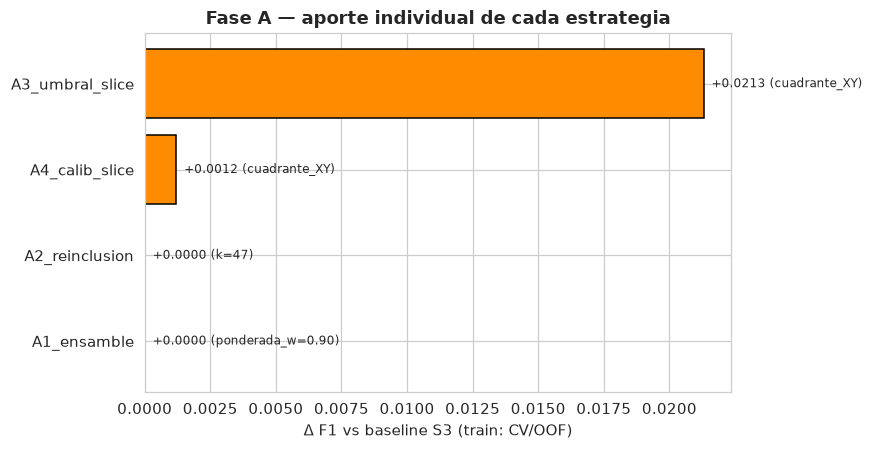

In [21]:
# --- Gráfico Fase A: Δ F1 por estrategia (igual peso) ---
fig, ax = plt.subplots(figsize=(8, 4.2))
cols = [ENS_COLOR if d > 0 else 'lightgray' for d in fase_a['delta']]
ax.barh(fase_a['estrategia'], fase_a['delta'], color=cols, edgecolor='black')
ax.axvline(0, color='black', lw=1)
for i, (d, det) in enumerate(zip(fase_a['delta'], fase_a['detalle'])):
    ax.text(d, i, f'  {d:+.4f} ({det})', va='center',
            ha='left' if d >= 0 else 'right', fontsize=8)
ax.set_xlabel('Δ F1 vs baseline S3 (train: CV/OOF)')
ax.set_title('Fase A — aporte individual de cada estrategia', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig('outputs_sprint4/fase_a_delta.png', bbox_inches='tight'); plt.show()

## Combinación 

In [22]:
# OOF de la probabilidad base según A2 (si mejoró); si k=47 coincide con S3
if 'A2_reinclusion' in ganan and k_A2 != len(set_S3):
    print(f'Calculando OOF calibrado para el set A2 (k={k_A2}) ...')
    fac_a2 = lambda: CalibratedClassifierCV(make_pipe(PARAMS_S3), method=CALIBRACION, cv=3)
    p_A2_oof = oof_proba(fac_a2, X_S2_tr[feats_A2], y_train)
else:
    p_A2_oof = p_S3_oof

def combinar_A1(p3, p2):
    '''Aplica la variante ganadora de A1 (simple / ponderada / rango) a dos vectores de prob.'''
    if nomA1 == 'rank_average':
        return 0.5 * (rankdata(p2) / len(p2) + rankdata(p3) / len(p3))
    return wA1 * p3 + (1 - wA1) * p2      # simple (w=0.5) o ponderada (w=w_opt)

def prob_base_combo(active):
    p = p_A2_oof if 'A2_reinclusion' in active else p_S3_oof
    if 'A1_ensamble' in active:
        p = combinar_A1(p, p_S2_oof)
    return p

def eval_combo(active):
    '''F1_OOF de una combinación de estrategias (capas A2→A1→A4→A3).'''
    p = prob_base_combo(active)
    if 'A4_calib_slice' in active:
        p = recalibrar_kfold(p, yv, arr=(PARTICIONES[part_A4] if A4_MODO == 'por_slice' else None))
    if 'A3_umbral_slice' in active:
        f1c, _, _ = f1_umbral_por_slice(PARTICIONES[part_A3], p, yv, best_thr_f1(yv, p)[0])
        return f1c
    return best_thr_f1(yv, p)[1]

In [23]:
# --- Forward incremental ---
orden_fb = fase_a[fase_a['mejora']]['estrategia'].tolist()   # ya ordenadas por Δ desc
activo, f1_prev, traza = [], F1_BASE_OOF, []
for estr in orden_fb:
    cand = activo + [estr]
    f = eval_combo(set(cand))
    sube = f > f1_prev + 1e-6
    traza.append({'paso': len(traza) + 1, 'anade': estr, 'combo': '+'.join(cand),
                  'F1_OOF': round(f, 4), 'delta_acum': round(f - F1_BASE_OOF, 4), 'aceptada': sube})
    print(f'  +{estr:<18} → F1_OOF={f:.4f} ({"ACEPTA" if sube else "DETIENE"})')
    if sube:
        activo, f1_prev = cand, f
    else:
        break

COMBO_GANADORA = activo
F1_COMBO_OOF = f1_prev
fb_tab = pd.DataFrame(traza) if traza else pd.DataFrame(
    [{'paso': 0, 'anade': '(ninguna)', 'combo': 'baseline_S3', 'F1_OOF': round(F1_BASE_OOF, 4),
      'delta_acum': 0.0, 'aceptada': False}])
fb_tab.to_csv('outputs_sprint4/fase_b_forward.csv', index=False)
print(fb_tab.to_string(index=False))
print(f'Combinación ganadora: {coral(COMBO_GANADORA if COMBO_GANADORA else "baseline S3")} '
      f'| F1_OOF={coral(f"{F1_COMBO_OOF:.4f}")} (Δ={F1_COMBO_OOF-F1_BASE_OOF:+.4f} vs base)')

  +A3_umbral_slice    → F1_OOF=0.7920 (ACEPTA)
  +A4_calib_slice     → F1_OOF=0.7839 (DETIENE)
 paso           anade                          combo  F1_OOF  delta_acum  aceptada
    1 A3_umbral_slice                A3_umbral_slice  0.7920      0.0213      True
    2  A4_calib_slice A3_umbral_slice+A4_calib_slice  0.7839      0.0132     False
Combinación ganadora: ['A3_umbral_slice'] | F1_OOF=0.7920 (Δ=+0.0213 vs base)


In [24]:
COMBO = set(COMBO_GANADORA)

# (1) Probabilidad base en TRAIN-OOF y en HOLD-OUT (ajuste sobre TODO el training)
feats_fin = feats_A2 if 'A2_reinclusion' in COMBO else set_S3
mdl_s3 = CalibratedClassifierCV(make_pipe(PARAMS_S3), method=CALIBRACION, cv=5)
mdl_s3.fit(X_S2_tr[feats_fin], y_train)
p3_ho = mdl_s3.predict_proba(X_S2_te[feats_fin])[:, 1]
p3_oof_fin = p_A2_oof if 'A2_reinclusion' in COMBO else p_S3_oof

if 'A1_ensamble' in COMBO:
    mdl_s2 = make_pipe(PARAMS_S2); mdl_s2.fit(X_S2_tr, y_train)
    p2_ho = mdl_s2.predict_proba(X_S2_te)[:, 1]
    p_ho = combinar_A1(p3_ho, p2_ho)
    p_oof_fin = combinar_A1(p3_oof_fin, p_S2_oof)
else:
    p_ho, p_oof_fin = p3_ho, p3_oof_fin

# (2) Calibración isotónica (A4) ajustada en TRAIN y aplicada a HOLD-OUT.
#     Los isotónicos se ajustan sobre las OOF CRUDAS de esta capa (p_oof_raw_layer);
#     el vector OOF (p_oof_fin) se recalibra de forma honesta por KFold.
dec_s2_te = ((mdl_s2.predict_proba(X_S2_te)[:, 1] if 'A1_ensamble' in COMBO
             else p3_ho) >= 0.5).astype(int)
dec_s3_te = (p3_ho >= UMBRAL_BASE).astype(int)
PART_TE = construir_particiones(X_test, AUX_te, dec_s2_te, dec_s3_te)
if 'A4_calib_slice' in COMBO:
    p_oof_raw_layer = p_oof_fin.copy()            # OOF crudas antes de calibrar
    ir_glob = IsotonicRegression(out_of_bounds='clip').fit(p_oof_raw_layer, yv)
    if A4_MODO == 'por_slice':
        arr_tr, arr_te = PARTICIONES[part_A4], PART_TE[part_A4]
        p_oof_fin = recalibrar_kfold(p_oof_raw_layer, yv, arr=arr_tr)
        ir_map = {}
        for cat in pd.unique(arr_tr):
            mtr = (arr_tr == cat)
            if mtr.sum() >= 20 and len(np.unique(yv[mtr])) == 2:
                ir_map[cat] = IsotonicRegression(out_of_bounds='clip').fit(
                    p_oof_raw_layer[mtr], yv[mtr])
        p_ho = np.array([ir_map.get(c, ir_glob).predict([v])[0]
                         for v, c in zip(p_ho, arr_te)])
    else:                                          # A4_MODO == 'global'
        p_oof_fin = recalibrar_kfold(p_oof_raw_layer, yv, arr=None)
        p_ho = ir_glob.predict(p_ho)

In [25]:
# (3) Umbral (global o por slice A3) fijado con TRAIN-OOF y aplicado a HOLD-OUT
if 'A3_umbral_slice' in COMBO:
    _, thr_map_fin, _ = f1_umbral_por_slice(PARTICIONES[part_A3], p_oof_fin, yv,
                                            best_thr_f1(yv, p_oof_fin)[0])
    thr_glob_fin = best_thr_f1(yv, p_oof_fin)[0]
    arr_te3 = PART_TE[part_A3]
    y_pred_ho = np.array([(p >= thr_map_fin.get(c, thr_glob_fin))
                          for p, c in zip(p_ho, arr_te3)]).astype(int)
    UMBRAL_FIN = thr_map_fin
else:
    UMBRAL_FIN = best_thr_f1(yv, p_oof_fin)[0]
    y_pred_ho = (p_ho >= UMBRAL_FIN).astype(int)

metr = {
    'F1':        f1_score(y_test, y_pred_ho),
    'Precision': precision_score(y_test, y_pred_ho, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_ho, zero_division=0),
    'AUC_ROC':   roc_auc_score(y_test, p_ho),
    'AUC_PR':    average_precision_score(y_test, p_ho),
    'Brier':     brier_score_loss(y_test, p_ho),
}
print('════════ HOLD-OUT (Sprint 4, informativo) ════════')
for k, v in metr.items():
    print(f'  {k:<10}: {v:.4f}')
print(f'  F1 hold-out S3 (referencia): {F1_HO_S3:.4f} | Δ = {metr["F1"]-F1_HO_S3:+.4f}')

════════ HOLD-OUT (Sprint 4, informativo) ════════
  F1        : 0.6593
  Precision : 0.7692
  Recall    : 0.5769
  AUC_ROC   : 0.9607
  AUC_PR    : 0.8274
  Brier     : 0.0452
  F1 hold-out S3 (referencia): 0.7619 | Δ = -0.1026


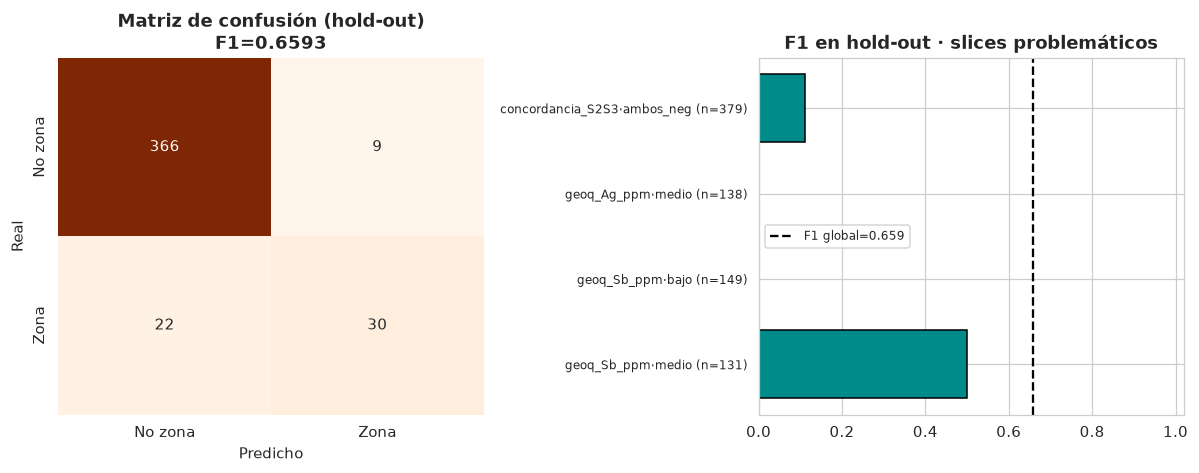

In [26]:
# (4) Matriz de confusión + F1 por slice problemático en hold-out
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
cm = confusion_matrix(y_test, y_pred_ho)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[0],
            xticklabels=['No zona', 'Zona'], yticklabels=['No zona', 'Zona'])
axes[0].set_title(f'Matriz de confusión (hold-out)\nF1={metr["F1"]:.4f}', fontweight='bold')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

if len(PROBLEMATICOS):
    filas_p = []
    for _, r in PROBLEMATICOS.iterrows():
        arrp = PART_TE.get(r['slice'])
        if arrp is None:
            continue
        m = (arrp == r['categoria'])
        if m.sum() >= 5 and y_test.values[m].sum() >= 1:
            filas_p.append((f"{r['slice']}·{r['categoria']}",
                            f1_score(y_test.values[m], y_pred_ho[m], zero_division=0), int(m.sum())))
    if filas_p:
        labs, f1s_p, ns = zip(*filas_p)
        axes[1].barh(range(len(labs)), f1s_p, color=S3_COLOR, edgecolor='black')
        axes[1].axvline(metr['F1'], ls='--', color='black', label=f'F1 global={metr["F1"]:.3f}')
        axes[1].set_yticks(range(len(labs)))
        axes[1].set_yticklabels([f'{l} (n={n})' for l, n in zip(labs, ns)], fontsize=8)
        axes[1].invert_yaxis(); axes[1].set_xlim(0, 1.02); axes[1].legend(fontsize=8)
    axes[1].set_title('F1 en hold-out · slices problemáticos', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Sin slices problemáticos', ha='center', va='center')
    axes[1].axis('off')
plt.tight_layout(); plt.savefig('outputs_sprint4/holdout_final.png', bbox_inches='tight'); plt.show()

## Resumen

In [27]:
fase_a_dict = fase_a.to_dict(orient='records')
resumen4 = {
    'sprint': 4,
    'nombre': 'Estrategias finales de mitigación (cierre): Fase A individual + Fase B forward',
    'protocolo': 'Igual peso por estrategia; decisión por F1_CV/OOF; hold-out una sola vez.',
    'modelo_base': 'LightGBM (S3: 47 features, calibración isotónica, umbral OOF)',
    'balanceo': BALANCEO,
    # --- punto de partida (S3) ---
    'f1_cv_s3': round(F1_CV_S3, 4),
    'f1_holdout_s3': round(F1_HO_S3, 4),
    'f1_base_oof_s3': round(F1_BASE_OOF, 4),
    'umbral_base_oof': round(UMBRAL_BASE, 4),
    # --- Paso 1: slices ---
    'elementos_base_shap': ELEM_BASE_SHAP,
    'slices_decisorios': list(PARTICIONES.keys()),
    'slices_observacion': list(OBSERVA.keys()),
    'n_slices_problematicos': int(len(PROBLEMATICOS)),
    'slices_problematicos': PROBLEMATICOS[['slice', 'categoria', 'n', 'F1', 'IC95_sup']].to_dict('records'),
    # --- Fase A ---
    'fase_a': fase_a_dict,
    'A1_mejor_variante': nomA1,
    'A2_mejor_k': int(k_A2),
    'A3_mejor_particion': part_A3,
    'A4_modo': A4_MODO,
    'A4_aporta': APORTA_A4,
    # --- Fase B ---
    'combo_ganadora': COMBO_GANADORA,
    'f1_combo_oof': round(F1_COMBO_OOF, 4),
    'mejora_oof_vs_s3': round(F1_COMBO_OOF - F1_BASE_OOF, 4),
    'forward_traza': fb_tab.to_dict('records'),
    # --- hold-out (informativo) ---
    'metricas_finales': {k: round(v, 4) for k, v in metr.items()},
    'mejora_holdout_vs_s3': round(metr['F1'] - F1_HO_S3, 4),
    # --- evolución ---
    'evolucion_f1_cv': {'sprint0': 0.7090, 'sprint1': 0.7277, 'sprint2': 0.7540, 'sprint3': 0.7706},
}
with open('outputs_sprint4/resumen_sprint4.json', 'w') as f:
    json.dump(resumen4, f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 4 ════════════════════')
print(f'Baseline S3 (OOF): {F1_BASE_OOF:.4f} | Combinación ganadora: {COMBO_GANADORA if COMBO_GANADORA else "baseline"}')
print(f'F1_OOF S4: {F1_COMBO_OOF:.4f} (Δ={F1_COMBO_OOF-F1_BASE_OOF:+.4f} vs baseline S3 OOF)')
print(f'F1 hold-out S4: {metr["F1"]:.4f} (S3={F1_HO_S3:.4f}, Δ={metr["F1"]-F1_HO_S3:+.4f})')

════════════════════ RESUMEN SPRINT 4 ════════════════════
Baseline S3 (OOF): 0.7707 | Combinación ganadora: ['A3_umbral_slice']
F1_OOF S4: 0.7920 (Δ=+0.0213 vs baseline S3 OOF)
F1 hold-out S4: 0.6593 (S3=0.7619, Δ=-0.1026)


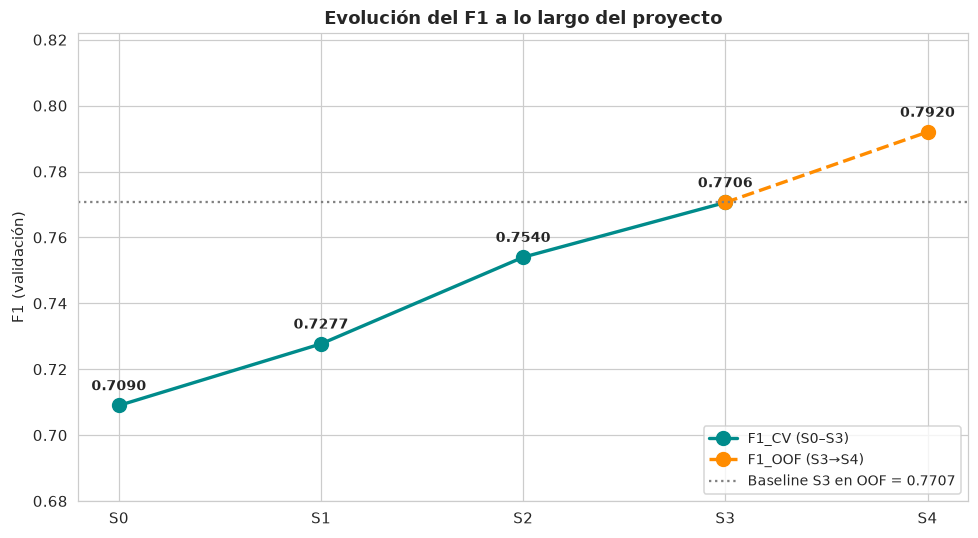

In [28]:
# --- Evolución del proyecto ---
sprints = ['S0', 'S1', 'S2', 'S3', 'S4']
f1_hist = [0.7090, 0.7277, 0.7540, 0.7706, F1_COMBO_OOF]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sprints[:4], f1_hist[:4], 'o-', color=S3_COLOR, lw=2.2, ms=9, label='F1_CV (S0–S3)')
ax.plot(sprints[3:], f1_hist[3:], 'o--', color=ENS_COLOR, lw=2.2, ms=9, label='F1_OOF (S3→S4)')
for i, (s, f) in enumerate(zip(sprints, f1_hist)):
    ax.annotate(f'{f:.4f}', (i, f), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold')
ax.axhline(F1_BASE_OOF, ls=':', color='gray', label=f'Baseline S3 en OOF = {F1_BASE_OOF:.4f}')
ax.set_ylabel('F1 (validación)'); ax.set_ylim(0.68, max(f1_hist) + 0.03)
ax.set_title('Evolución del F1 a lo largo del proyecto', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint4/evolucion_f1.png', bbox_inches='tight'); plt.show()